<h1 align="center" id="top"><u>RL project</u></h1>
<h3 align="center"><u>Clément MOLLY-MITTON | Diane VERBECQ | Fanny BADOULES | Ghiles KEMICHE</u></h3>

# Table of Contents
***
1. [Import](#import)
2. [Testing](#testing)

## Import
***

In [1]:
from pathlib import Path

from rl_project.benchmark.benchmark import HighwayBenchmark
from rl_project.benchmark.typing import BenchmarkConfig
from rl_project.models.core.typing import ModelType
from rl_project.models.dqn.model import DQNModel
from scripts.utils.benchmark_config import SHARED_CORE_CONFIG, SHARED_CORE_ENV_ID
from scripts.utils.display import display_episode

SHARED_CORE_CONFIG["offscreen_rendering"] = True

## Testing
***

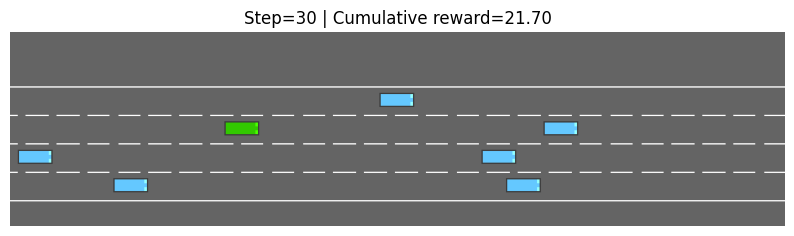

{'episode_reward': 21.702683696497495,
 'episode_length': 30,
 'crashed': False,
 'offroad': False,
 'mean_speed': 21.701018335070977}

In [2]:
benchmark_config = BenchmarkConfig(
    env_id=SHARED_CORE_ENV_ID,
    env_config=SHARED_CORE_CONFIG,
)

benchmark = HighwayBenchmark(
    config=benchmark_config,
    render_mode="rgb_array",
)

seed = 0
model_type = ModelType.DQN
env = benchmark.make_env(seed=seed)
model_path = (
    Path.cwd().parents[2]
    / "data"
    / "training"
    / model_type.value
    / f"seed_{seed}"
    / f"model_{model_type.value}_seed_{seed}.pt"
)
if model_type == ModelType.DQN:
    model = DQNModel.load(model_path)

stats = display_episode(
    env=env,
    model=model,
    greedy=True,
    sleep_time=0.03,
)
stats